# 03 — Preprocessing Pipeline

This notebook transforms the raw CFPB data into clean, tokenised, split datasets ready for transformer fine-tuning. Every decision is justified by findings from NB02 EDA and NLP domain best practices.

**What this notebook produces:**
- Cleaned narrative text with standardised redaction tokens
- Encoded classification labels for 3 targets: `product`, `issue`, `company_response`
- Temporal train/val/test splits (no data leakage)
- Token-length analysis per model tokeniser to confirm `max_length` budget
- Saved parquet files ready for PyTorch Dataset consumption in NB05–08

**EDA findings driving preprocessing decisions:**

| EDA Finding | Preprocessing Action |
|---|---|
| CFPB uses Title Case column names | Apply rename_map on load |
| ~12-15% of complaints have narrative text | Filter to narrative-only subset |
| Non-English narratives may exist | Detect and filter to English-only |
| Ghost narratives (<10 real words after XXXX removal) | Exclude |
| Exact duplicate narratives exist | Deduplicate before splitting |
| XXXX/XX redaction patterns (~5-10 per complaint) | Normalise to single `[REDACTED]` token |
| ALL CAPS frustration text | Lowercase with caps-ratio feature preserved |
| Issue long-tail (80% coverage in ~10 issues) | Collapse rare issues into 'Other' |
| `consumer_disputed` discontinued April 2017 | Exclude as target |
| Temporal drift in product mix | Temporal split, not random |
| 90th percentile ~400-500 words | Confirm max_length=512 via tokeniser analysis |

In [1]:
import os, re, warnings, json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

ROOT = Path('..').resolve()
RAW = ROOT / 'data' / 'raw'
PROCESSED = ROOT / 'data' / 'processed'
FIG = ROOT / 'reports' / 'figures'
PROCESSED.mkdir(parents=True, exist_ok=True)

print(f'Root: {ROOT}')

Root: C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project


## 1 — Load Raw Data with Standardised Column Names

Reuse the rename map from NB02. This is the canonical loading pattern for all downstream notebooks.

In [2]:
CSV_PATH = RAW / 'complaints.csv'
assert CSV_PATH.exists(), f'Raw CSV not found at {CSV_PATH}. Run NB02 first.'

rename_map = {
    'Date received':                 'date_received',
    'Product':                       'product',
    'Sub-product':                   'sub_product',
    'Issue':                         'issue',
    'Sub-issue':                     'sub_issue',
    'Consumer complaint narrative':  'narrative',
    'Company public response':       'company_public_response',
    'Company':                       'company',
    'State':                         'state',
    'ZIP code':                      'zip_code',
    'Tags':                          'tags',
    'Consumer consent provided?':    'consumer_consent',
    'Submitted via':                 'submitted_via',
    'Date sent to company':          'date_sent_to_company',
    'Company response to consumer':  'company_response',
    'Timely response?':              'timely_response',
    'Consumer disputed?':            'consumer_disputed',
    'Complaint ID':                  'complaint_id',
}

print('Loading raw CFPB CSV...')
df = pd.read_csv(CSV_PATH, low_memory=False)
df.rename(columns=rename_map, inplace=True)
df['date_received'] = pd.to_datetime(df['date_received'], errors='coerce')
df['date_sent_to_company'] = pd.to_datetime(df['date_sent_to_company'], errors='coerce')

print(f'Full dataset: {len(df):,} rows, {df.shape[1]} columns')

Loading raw CFPB CSV...
Full dataset: 13,906,793 rows, 18 columns


## 2 — Filter to Narrative Subset

Only ~12-15% of complaints have published consumer narratives. We filter to this subset since our NLP models require text input. All metadata columns are preserved for potential feature engineering.

In [3]:
before = len(df)
df = df[df['narrative'].notna()].copy()
print(f'Filtered to narratives: {before:,} → {len(df):,} ({len(df)/before:.1%})')

Filtered to narratives: 13,906,793 → 3,740,313 (26.9%)


## 3 — Remove Ghost Narratives

**EDA finding:** Some narratives are effectively empty — just strings of XXXX redaction tokens with no usable content. These produce near-zero information for the model.

**Action:** Exclude any narrative with fewer than 10 real words (words that are not XXXX/XX patterns and are longer than 1 character).

In [4]:
def count_real_words(text):
    """Count words that are not XXXX redaction patterns and have >1 character."""
    words = str(text).split()
    return sum(1 for w in words if not re.fullmatch(r'X{2,}', w) and len(w) > 1)

df['real_word_count'] = df['narrative'].apply(count_real_words)

ghost_mask = df['real_word_count'] < 10
n_ghosts = ghost_mask.sum()
print(f'Ghost narratives (<10 real words): {n_ghosts:,} ({n_ghosts/len(df):.2%})')

if n_ghosts > 0:
    print('\nExamples of removed ghost narratives:')
    for _, row in df[ghost_mask].head(3).iterrows():
        print(f'  "{str(row["narrative"])[:120]}..."')

before = len(df)
df = df[~ghost_mask].copy()
print(f'\nAfter ghost removal: {before:,} → {len(df):,}')

Ghost narratives (<10 real words): 41,068 (1.10%)

Examples of removed ghost narratives:
  "These are not my accounts...."
  "Unauthorized and unverified accounts appear on my credit report..."
  "XXXX can financial hippa violations or ftc or both..."

After ghost removal: 3,740,313 → 3,699,245


## 4 — Deduplicate Narratives

**EDA finding:** Exact duplicate narratives exist (resubmissions, template complaints from law firms). Keeping duplicates risks data leakage if the same text lands in both train and test.

**Action:** Drop exact-match duplicates, keeping the earliest submission (first occurrence by date).

In [5]:
df = df.sort_values('date_received')  # keep earliest
before = len(df)
df = df.drop_duplicates(subset='narrative', keep='first')
n_removed = before - len(df)
print(f'Deduplicated: {before:,} → {len(df):,} (removed {n_removed:,} exact duplicates, {n_removed/before:.2%})')

Deduplicated: 3,699,245 → 2,474,632 (removed 1,224,613 exact duplicates, 33.10%)


## 5 — Language Filtering

**EDA finding:** A small proportion of narratives may be non-English. Our transformer models (DeBERTaV3, ModernBERT, NeoBERT) are English-centric. Non-English text would produce garbage tokenisation and hurt classification.

**Action:** Detect language on a sample. If >0.5% non-English, filter the full dataset. If negligible, skip.

In [6]:
try:
    from langdetect import detect, LangDetectException
    HAS_LANGDETECT = True
except ImportError:
    print('langdetect not installed. Run: pip install langdetect')
    print('Skipping language filtering — assume English-only.')
    HAS_LANGDETECT = False

In [7]:
if HAS_LANGDETECT:
    def safe_detect(text):
        try:
            return detect(str(text)[:1000])
        except LangDetectException:
            return 'unknown'

    # Sample for speed
    sample_size = min(15_000, len(df))
    lang_sample = df['narrative'].sample(sample_size, random_state=42)
    print(f'Detecting language on {sample_size:,} samples...')
    langs = lang_sample.apply(safe_detect)
    
    non_en_rate = (langs != 'en').mean()
    print(f'Non-English rate in sample: {non_en_rate:.2%}')
    
    if non_en_rate > 0.005:  # >0.5%
        print('\n→ Non-trivial non-English content detected. Filtering full dataset...')
        print('  (This may take a few minutes on the full dataset)')
        tqdm.pandas(desc='Language detection')
        df['lang'] = df['narrative'].progress_apply(safe_detect)
        before = len(df)
        df = df[df['lang'] == 'en'].copy()
        df.drop(columns=['lang'], inplace=True)
        print(f'  Filtered: {before:,} → {len(df):,} (removed {before - len(df):,} non-English)')
    else:
        print('→ Negligible non-English content. No filtering needed.')
else:
    print('Skipped language detection (langdetect not available).')

Detecting language on 15,000 samples...
Non-English rate in sample: 2.07%

→ Non-trivial non-English content detected. Filtering full dataset...
  (This may take a few minutes on the full dataset)


Language detection:   0%|          | 0/2474632 [00:00<?, ?it/s]

  Filtered: 2,474,632 → 2,421,498 (removed 53,134 non-English)


## 6 — Text Cleaning Pipeline

Designed specifically for CFPB complaint narratives based on EDA observations:

| Pattern | Action | Justification |
|---|---|---|
| `XXXX`, `XX`, `XXXXX` (variable-length) | Replace with `[REDACTED]` | Standardise PII placeholders into a single learnable token |
| Multiple consecutive `[REDACTED]` | Collapse to one | Sequences like `XXXX XXXX XXXX` become one token, not three |
| URLs | Replace with `[URL]` | Rare but present; not informative for classification |
| Dollar amounts (`$1,234.56`) | Replace with `[AMOUNT]` | Preserves semantic meaning ("money was involved") without memorising specific values |
| Dates (various formats) | Replace with `[DATE]` | Same rationale as amounts |
| Long account/reference numbers | Replace with `[ACCOUNT]` | Noise reduction |
| ALL CAPS sequences (>3 consecutive words) | Convert to Title Case | Preserves emphasis without creating vocabulary explosion; caps_ratio stored as metadata feature |
| Excessive punctuation (`!!!`, `???`) | Collapse to single | Reduces noise while preserving the signal that punctuation existed |
| Whitespace/newlines | Normalise to single space | Clean for tokeniser input |

**What we intentionally do NOT do:**
- **No lowercasing of all text.** Transformer tokenisers handle casing internally (DeBERTaV3 is cased). Lowercasing destroys useful signal (e.g., proper nouns, acronyms like APR, FCRA, FDCPA).
- **No stopword removal.** Subword tokenisers handle common words natively. Removing stopwords breaks phrase structure that attention mechanisms depend on.
- **No lemmatisation/stemming.** These are pre-neural-era techniques. Transformers learn morphological patterns from raw text.

In [8]:
def clean_cfpb_narrative(text: str) -> str:
    """
    Production-grade cleaning for CFPB complaint narratives.
    Designed for transformer consumption — preserves casing,
    phrase structure, and domain vocabulary.
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return ''
    
    # 1. Normalise XXXX redaction patterns → single [REDACTED] token
    text = re.sub(r'\bX{2,}\b', '[REDACTED]', text)
    # Collapse consecutive [REDACTED] tokens (e.g., "[REDACTED] [REDACTED] [REDACTED]" → "[REDACTED]")
    text = re.sub(r'(\[REDACTED\]\s*){2,}', '[REDACTED] ', text)
    
    # 2. Replace URLs
    text = re.sub(r'https?://\S+|www\.\S+', '[URL]', text)
    
    # 3. Replace dollar amounts (preserve semantic signal)
    text = re.sub(r'\$[\d,]+\.?\d*', '[AMOUNT]', text)
    
    # 4. Replace dates (multiple formats)
    text = re.sub(r'\b\d{1,2}/\d{1,2}/\d{2,4}\b', '[DATE]', text)
    text = re.sub(r'\b\d{1,2}-\d{1,2}-\d{2,4}\b', '[DATE]', text)
    
    # 5. Replace long numeric sequences (account numbers, phone numbers)
    text = re.sub(r'\b\d{7,}\b', '[ACCOUNT]', text)
    text = re.sub(r'\b\d{3}[-.]\d{3}[-.]\d{4}\b', '[PHONE]', text)
    
    # 6. Handle ALL CAPS sequences (>3 consecutive CAPS words → Title Case)
    def lowercase_caps_run(match):
        return match.group(0).title()
    text = re.sub(r'\b(?:[A-Z]{2,}\s+){3,}[A-Z]{2,}\b', lowercase_caps_run, text)
    
    # 7. Collapse excessive punctuation
    text = re.sub(r'([!?.]){2,}', r'\1', text)
    text = re.sub(r'[-]{3,}', '—', text)  # long dashes
    
    # 8. Remove email signatures / boilerplate (common patterns)
    text = re.sub(
        r'(Sent from my|Best regards|Kind regards|Regards|Sincerely).*',
        '', text, flags=re.DOTALL | re.IGNORECASE
    )
    
    # 9. Normalise whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text


def compute_caps_ratio(text: str) -> float:
    """Fraction of alphabetic characters that are uppercase. Metadata feature."""
    alpha_chars = [c for c in str(text) if c.isalpha()]
    if not alpha_chars:
        return 0.0
    return sum(1 for c in alpha_chars if c.isupper()) / len(alpha_chars)


print('Cleaning function defined. Testing on a sample...')

# Quick test
test_text = 'I called XXXX XXXX on XX/XX/2023 about my $1,500.00 payment. THEY DID NOT HELP ME AT ALL!!! My account 123456789 was NEVER fixed. Sent from my iPhone'
print(f'Before: {test_text}')
print(f'After:  {clean_cfpb_narrative(test_text)}')

Cleaning function defined. Testing on a sample...
Before: I called XXXX XXXX on XX/XX/2023 about my $1,500.00 payment. THEY DID NOT HELP ME AT ALL!!! My account 123456789 was NEVER fixed. Sent from my iPhone
After:  I called [REDACTED] on [REDACTED]/[REDACTED]/2023 about my [AMOUNT] payment. They Did Not Help Me At All! My account [ACCOUNT] was NEVER fixed.


In [9]:
# Apply cleaning to all narratives
print(f'Cleaning {len(df):,} narratives...')

# Preserve original for comparison
df['narrative_raw'] = df['narrative'].copy()

# Compute caps ratio BEFORE cleaning (on raw text)
df['caps_ratio'] = df['narrative_raw'].apply(compute_caps_ratio)

# Apply cleaning
tqdm.pandas(desc='Cleaning narratives')
df['narrative'] = df['narrative_raw'].progress_apply(clean_cfpb_narrative)

# Recompute word count on cleaned text
df['word_count'] = df['narrative'].str.split().str.len()

# Verify no empty results after cleaning
empty_after_clean = (df['word_count'] < 5).sum()
print(f'\nNarratives with <5 words after cleaning: {empty_after_clean:,}')
if empty_after_clean > 0:
    df = df[df['word_count'] >= 5].copy()
    print(f'Removed {empty_after_clean:,} near-empty cleaned narratives.')

print(f'\nFinal narrative count: {len(df):,}')

Cleaning 2,421,498 narratives...


ValueError: not enough values to unpack (expected at least 1, got 0)

Cleaning narratives:   0%|          | 0/2421498 [00:00<?, ?it/s]


Narratives with <5 words after cleaning: 2,278
Removed 2,278 near-empty cleaned narratives.

Final narrative count: 2,419,220


In [10]:
# Show before/after examples
examples = df.sample(3, random_state=42)
for _, row in examples.iterrows():
    print(f'PRODUCT: {row["product"]}')
    print(f'RAW:     {str(row["narrative_raw"])[:200]}...')
    print(f'CLEAN:   {str(row["narrative"])[:200]}...')
    print(f'Caps ratio: {row["caps_ratio"]:.2f} | Words: {row["word_count"]}')
    print()

PRODUCT: Debt collection
RAW:     Following up on contents received as a result of CFPB complaint XXXX. 

This company never obtain permissible purpose in order to furnish any account on my consumer report. In addition to that Charges...
CLEAN:   Following up on contents received as a result of CFPB complaint [REDACTED]. This company never obtain permissible purpose in order to furnish any account on my consumer report. In addition to that Cha...
Caps ratio: 0.04 | Words: 169

PRODUCT: Credit reporting, credit repair services, or other personal consumer reports
RAW:     In short, XXXX has reported missed payments on my credit report in XX/XX/XXXX months of XXXX. I returned the vehicle in XX/XX/XXXX and no further reporting should be notated on my credit profile. As a...
CLEAN:   In short, [REDACTED] has reported missed payments on my credit report in [REDACTED]/[REDACTED]/[REDACTED] months of [REDACTED]. I returned the vehicle in [REDACTED]/[REDACTED]/[REDACTED] and no furthe...
Caps r

## 7 — Label Encoding

We encode three classification targets:

1. **`product`** (primary target) — The CFPB has renamed/reorganised product categories multiple times. We map old names to their current equivalents.
2. **`issue`** (secondary target) — Long-tail distribution. Collapse rare issues into 'Other' (keep top N that cover ~90% of complaints).
3. **`company_response`** (RL reward signal / tertiary target) — Keep the 5 meaningful response types. Exclude 'In progress' and other administrative responses.

**Excluded targets:**
- `consumer_disputed` — discontinued April 2017, blank for 6+ years of data.
- `sub_product` — too many classes, high missingness. Available as auxiliary feature but not a training target.
- `sub_issue` — same rationale as sub_product.

In [11]:
# ─── Harmonise CFPB product taxonomy changes over time ───
# The CFPB has renamed/reorganised product categories multiple times.
# We map old names to their current equivalents.

product_harmonise = {
    'Credit reporting, credit repair services, or other personal consumer reports':
        'Credit reporting or other personal consumer reports',
    'Credit reporting':
        'Credit reporting or other personal consumer reports',
    'Credit card or prepaid card':  'Credit card',
    'Prepaid card':                 'Credit card',
    'Bank account or service':      'Checking or savings account',
    'Consumer Loan':                'Payday loan, title loan, personal loan, or advance loan',
    'Payday loan':                  'Payday loan, title loan, personal loan, or advance loan',
    'Payday loan, title loan, or personal loan':
        'Payday loan, title loan, personal loan, or advance loan',
    'Money transfers':              'Money transfer, virtual currency, or money service',
    'Virtual currency':             'Money transfer, virtual currency, or money service',
    'Other financial service':      'Money transfer, virtual currency, or money service',
}

before_classes = df['product'].nunique()
df['product'] = df['product'].replace(product_harmonise)
after_classes = df['product'].nunique()

print(f'Product harmonisation: {before_classes} → {after_classes} classes')
print(f'\nHarmonised product distribution:')
for prod, count in df['product'].value_counts().items():
    print(f'  {prod:60s} {count:>9,} ({count/len(df)*100:.1f}%)')

Product harmonisation: 21 → 10 classes

Harmonised product distribution:
  Credit reporting or other personal consumer reports          1,301,753 (53.8%)
  Debt collection                                                343,426 (14.2%)
  Credit card                                                    213,667 (8.8%)
  Checking or savings account                                    179,098 (7.4%)
  Mortgage                                                       139,356 (5.8%)
  Money transfer, virtual currency, or money service              89,059 (3.7%)
  Student loan                                                    58,643 (2.4%)
  Vehicle loan or lease                                           47,262 (2.0%)
  Payday loan, title loan, personal loan, or advance loan         42,515 (1.8%)
  Debt or credit management                                        4,441 (0.2%)


In [12]:
# ─── Product encoding (all classes) ───
product_encoder = LabelEncoder()
df['product_id'] = product_encoder.fit_transform(df['product'].astype(str))
n_products = len(product_encoder.classes_)

print(f'Product classes: {n_products}')
for i, cls in enumerate(product_encoder.classes_):
    count = (df['product_id'] == i).sum()
    print(f'  {i:2d}: {cls:50s} ({count:>8,})')

Product classes: 10
   0: Checking or savings account                        ( 179,098)
   1: Credit card                                        ( 213,667)
   2: Credit reporting or other personal consumer reports (1,301,753)
   3: Debt collection                                    ( 343,426)
   4: Debt or credit management                          (   4,441)
   5: Money transfer, virtual currency, or money service (  89,059)
   6: Mortgage                                           ( 139,356)
   7: Payday loan, title loan, personal loan, or advance loan (  42,515)
   8: Student loan                                       (  58,643)
   9: Vehicle loan or lease                              (  47,262)


In [13]:
# ─── Issue encoding (collapse rare into 'Other') ───
# Keep issues that cover 90% of complaints
issue_counts = df['issue'].value_counts()
cum_pct = issue_counts.cumsum() / issue_counts.sum()
n_keep = (cum_pct <= 0.90).sum() + 1  # +1 to include the one that crosses 90%
top_issues = issue_counts.head(n_keep).index.tolist()

print(f'Keeping top {n_keep} issues (cover {cum_pct.iloc[n_keep-1]:.1%} of complaints).')
print(f'Collapsing remaining {len(issue_counts) - n_keep} rare issues into "Other".')

df['issue_clean'] = df['issue'].astype(str).where(
    df['issue'].isin(top_issues), other='Other'
)

issue_encoder = LabelEncoder()
df['issue_id'] = issue_encoder.fit_transform(df['issue_clean'])
n_issues = len(issue_encoder.classes_)

print(f'\nIssue classes after collapse: {n_issues}')
for i, cls in enumerate(issue_encoder.classes_):
    count = (df['issue_id'] == i).sum()
    print(f'  {i:2d}: {cls[:55]:55s} ({count:>8,})')

Keeping top 35 issues (cover 90.1% of complaints).
Collapsing remaining 138 rare issues into "Other".

Issue classes after collapse: 36
   0: Applying for a mortgage or refinancing an existing mort (  14,290)
   1: Attempts to collect debt not owed                       ( 140,662)
   2: Closing an account                                      (  23,426)
   3: Closing on a mortgage                                   (  10,259)
   4: Closing your account                                    (  14,350)
   5: Communication tactics                                   (  31,374)
   6: Cont'd attempts collect debt not owed                   (  16,495)
   7: Credit monitoring or identity theft protection services (  10,553)
   8: Dealing with your lender or servicer                    (  32,824)
   9: False statements or representation                      (  42,315)
  10: Fees or interest                                        (  21,165)
  11: Fraud or scam                                          

In [14]:
# ─── Company response encoding (RL reward signal) ───
# Keep only meaningful response types. Exclude administrative/in-progress.

valid_responses = [
    'Closed with explanation',
    'Closed with non-monetary relief',
    'Closed with monetary relief',
    'Closed',
    'Untimely response',
]

# Also define the RL reward mapping here (used in NB12)
response_reward_map = {
    'Closed with monetary relief':      1.0,
    'Closed with non-monetary relief':   0.75,
    'Closed with explanation':           0.3,
    'Closed':                            0.2,
    'Untimely response':                 0.0,
}

before = len(df)
df = df[df['company_response'].isin(valid_responses)].copy()
excluded = before - len(df)
print(f'Filtered to valid responses: {before:,} → {len(df):,} (excluded {excluded:,} admin/in-progress)')

response_encoder = LabelEncoder()
df['response_id'] = response_encoder.fit_transform(df['company_response'].astype(str))
n_responses = len(response_encoder.classes_)

# Also store the numeric reward
df['reward'] = df['company_response'].map(response_reward_map)

print(f'\nResponse classes: {n_responses}')
for i, cls in enumerate(response_encoder.classes_):
    count = (df['response_id'] == i).sum()
    reward = response_reward_map.get(cls, '?')
    print(f'  {i}: {cls:45s} ({count:>8,}) → reward={reward}')

Filtered to valid responses: 2,419,220 → 2,419,092 (excluded 128 admin/in-progress)

Response classes: 5
  0: Closed                                        (   3,608) → reward=0.2
  1: Closed with explanation                       (1,743,296) → reward=0.3
  2: Closed with monetary relief                   (  91,154) → reward=1.0
  3: Closed with non-monetary relief               ( 571,862) → reward=0.75
  4: Untimely response                             (   9,172) → reward=0.0


## 8 — Metadata Feature Engineering

Beyond the raw narrative text, we extract structured metadata features that can be concatenated with the [CLS] embedding in the multi-task model. These are cheap to compute and may carry predictive signal.

In [15]:
# Text-derived metadata
df['char_len'] = df['narrative'].str.len()
df['redacted_count'] = df['narrative'].str.count(re.escape('[REDACTED]'))
df['amount_count'] = df['narrative'].str.count(re.escape('[AMOUNT]'))
df['has_url'] = df['narrative'].str.contains(re.escape('[URL]'), na=False).astype(int)

# Routing time (from EDA)
df['routing_days'] = (df['date_sent_to_company'] - df['date_received']).dt.days
df['routing_days'] = df['routing_days'].clip(0, 365).fillna(-1)  # -1 = missing

# Submission channel (one-hot or label encode)
channel_encoder = LabelEncoder()
df['channel_id'] = channel_encoder.fit_transform(df['submitted_via'].astype(str))

# Timely response (binary)
df['is_timely'] = (df['timely_response'].astype(str) == 'Yes').astype(int)

metadata_cols = [
    'word_count', 'char_len', 'caps_ratio', 'redacted_count',
    'amount_count', 'has_url', 'routing_days', 'channel_id'
]

print('Metadata features computed:')
print(df[metadata_cols].describe().round(2).to_string())

Metadata features computed:
       word_count    char_len  caps_ratio  redacted_count  amount_count     has_url  routing_days  channel_id
count  2419092.00  2419092.00  2419092.00      2419092.00    2419092.00  2419092.00    2419092.00   2419092.0
mean       199.43     1199.03        0.13            9.40          0.93        0.00          1.04         0.0
std        235.53     1426.75        0.15           16.69          2.70        0.07          6.36         0.0
min          5.00       15.00        0.00            0.00          0.00        0.00          0.00         0.0
25%         74.00      435.00        0.05            1.00          0.00        0.00          0.00         0.0
50%        135.00      811.00        0.08            5.00          0.00        0.00          0.00         0.0
75%        246.00     1478.00        0.15           11.00          1.00        0.00          0.00         0.0
max       6414.00    37708.00        1.00         2272.00        586.00        1.00        3

## 9 — Temporal Train / Validation / Test Split

**EDA finding:** Product mix drifts over time (credit reporting grew from ~30% to ~80%). Random splitting would leak future distribution information into training.

**Split strategy:**
- **Train:** All narratives before 2025-01-01 (years of historical data)
- **Validation:** 2025-01-01 to 2025-06-30 (first half of 2025)
- **Test:** 2025-07-01 onwards (second half of 2025 — unseen temporal distribution)

This mirrors real deployment: the model is trained on historical data and must generalise to future complaints.

In [40]:
df

,date_received,product,sub_product,issue,sub_issue,narrative,company_public_response,company,state,zip_code,...,issue_id,response_id,reward,char_len,redacted_count,amount_count,has_url,routing_days,channel_id,is_timely
2747697,2015-03-19,Debt collection,Credit card,Cont'd attempts collect debt not owed,Debt was paid,We made several attempts to speak to someone a...,NaN,"Portfolio Recovery Associates, LLC",PA,19083,...,6,3,0.75,589,6,0,0,0,0,1
2857415,2015-03-19,Mortgage,Conventional fixed mortgage,"Loan modification,collection,foreclosure",NaN,Too Big To Fail And Care We are in our [REDACT...,Company chooses not to provide a public response,"BANK OF AMERICA, NATIONAL ASSOCIATION",GA,30058,...,16,1,0.30,1908,17,0,0,0,0,1
2135679,2015-03-19,Debt collection,I do not know,Cont'd attempts collect debt not owed,Debt is not mine,I mailed off several complaints to different a...,Company believes it acted appropriately as aut...,"Consumer Portfolio Services, Inc.",MD,XXXXX,...,6,1,0.30,750,1,0,0,6,0,1
13129724,2015-03-19,"Payday loan, title loan, personal loan, or adv...",Vehicle loan,Managing the loan or lease,NaN,I contacted Drivetime on several different occ...,NaN,DriveTime,FL,XXXXX,...,19,1,0.30,3135,28,0,0,20,0,1
3408394,2015-03-19,Student loan,Non-federal student loan,Can't repay my loan,Can't decrease my monthly payments,I am trying to deal with Navient ( formerly [R...,NaN,"Navient Solutions, LLC.",NY,14223,...,21,1,0.30,2829,7,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201265,2026-02-19,Checking or savings account,Checking account,Closing an account,Can't close your account,I've called multiple times stating I'm not usi...,Company has responded to the consumer and the ...,U.S. BANCORP,MI,49424,...,2,2,1.00,509,1,0,0,0,0,1
9531841,2026-02-19,Debt collection,Telecommunications debt,Written notification about debt,Didn't receive enough information to verify debt,"I didnt get a [REDACTED] letter, cure default ...",Company believes it acted appropriately as aut...,"MRS BPO, LLC",NE,68127,...,35,3,0.75,308,4,0,0,0,0,1
2643903,2026-02-19,Credit card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute ...,On [REDACTED]/[REDACTED]/year> I tried to use ...,Company has responded to the consumer and the ...,WELLS FARGO & COMPANY,OK,731XX,...,29,1,0.30,873,10,0,0,0,0,1
13033682,2026-02-19,Checking or savings account,Checking account,Managing an account,Problem using a debit or ATM card,"On [REDACTED]/[REDACTED]/year>, money was with...",Company has responded to the consumer and the ...,"CITIBANK, N.A.",NY,11421,...,18,1,0.30,977,8,0,0,0,0,1


In [41]:
train_mask = df['date_received'] < '2025-01-01'
val_mask = (df['date_received'] >= '2025-01-01') & (df['date_received'] < '2025-07-01')
test_mask = df['date_received'] >= '2025-07-01'

train_df = df[train_mask].copy()
val_df = df[val_mask].copy()
test_df = df[test_mask].copy()

print(f'Train: {len(train_df):>9,}  ({len(train_df)/len(df):.1%})  [{train_df["date_received"].min().date()} → {train_df["date_received"].max().date()}]')
print(f'Val:   {len(val_df):>9,}  ({len(val_df)/len(df):.1%})  [{val_df["date_received"].min().date()} → {val_df["date_received"].max().date()}]')
print(f'Test:  {len(test_df):>9,}  ({len(test_df)/len(df):.1%})  [{test_df["date_received"].min().date()} → {test_df["date_received"].max().date()}]')
print(f'Total: {len(train_df)+len(val_df)+len(test_df):>9,}')

Train: 1,813,849  (75.0%)  [2015-03-19 → 2024-12-31]
Val:     331,178  (13.7%)  [2025-01-01 → 2025-06-30]
Test:    274,065  (11.3%)  [2025-07-01 → 2026-02-19]
Total: 2,419,092


In [42]:
# Verify product distribution across splits (expect drift)
split_dist = pd.DataFrame({
    'Train %': train_df['product'].value_counts(normalize=True).mul(100).round(1),
    'Val %': val_df['product'].value_counts(normalize=True).mul(100).round(1),
    'Test %': test_df['product'].value_counts(normalize=True).mul(100).round(1),
}).fillna(0).sort_values('Train %', ascending=False)

print('Product distribution across temporal splits:')
print(split_dist.to_string())
print('\n→ Distribution drift between splits is expected and intentional.')
print('  This tests real-world generalisation under temporal shift.')

Product distribution across temporal splits:
                                                         Train %  Val %  Test %
product                                                                        
Credit reporting or other personal consumer reports         52.7   58.8    54.9
Debt collection                                             14.7   11.3    14.6
Credit card                                                  9.3    6.2     8.8
Checking or savings account                                  7.2    7.7     8.7
Mortgage                                                     6.9    2.0     2.9
Money transfer, virtual currency, or money service           2.7    8.9     4.1
Student loan                                                 2.6    2.1     1.4
Payday loan, title loan, personal loan, or advance loan      1.9    1.0     1.6
Vehicle loan or lease                                        1.9    1.6     2.4
Debt or credit management                                    0.1    0.4    

## ─── 9b: Class Distribution Check (Oversampling Removed) ───

Class 4 (Debt or credit management) has ~4,400 samples — smallest class but still substantial.
Class imbalance is handled at training time via `WeightedRandomSampler` in each model notebook,
not via data duplication here. This keeps the parquet files clean for all downstream consumers.


## 10 — Tokeniser Length Analysis

Before committing to `max_length=512`, we verify with actual transformer tokenisers. Different models tokenise differently — DeBERTaV3 (WordPiece/SentencePiece), ModernBERT (custom BPE), NeoBERT (BPE variant). Token count per narrative can vary 10-20% across tokenisers.

This analysis determines the optimal `max_length` and quantifies what fraction of narratives will be truncated.

In [43]:
from transformers import AutoTokenizer

# Load tokenisers for all three models we'll fine-tune
tokeniser_configs = {
    'DeBERTaV3-base': 'microsoft/deberta-v3-base',
    'ModernBERT-base': 'answerdotai/ModernBERT-base',
    'NeoBERT':         'chandar-lab/NeoBERT',
}

tokenisers = {}
for name, model_id in tokeniser_configs.items():
    try:
        tokenisers[name] = AutoTokenizer.from_pretrained(
            model_id, trust_remote_code=True
        )
        print(f'Loaded {name} tokeniser (vocab size: {tokenisers[name].vocab_size:,})')
    except Exception as e:
        print(f'Failed to load {name}: {e}')


Loaded DeBERTaV3-base tokeniser (vocab size: 128,000)
Loaded ModernBERT-base tokeniser (vocab size: 50,280)


Encountered exception while importing xformers: No module named 'xformers'
You are using a model of type `neobert` to instantiate a model of type ``. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


Loaded NeoBERT tokeniser (vocab size: 30,522)


In [44]:
# Tokenise a sample to get token-length distributions
tok_sample_n = min(20_000, len(train_df))
tok_sample = train_df['narrative'].sample(tok_sample_n, random_state=42).tolist()

token_lengths = {}
for name, tok in tokenisers.items():
    print(f'Tokenising {tok_sample_n:,} samples with {name}...')
    encoded = tok(tok_sample, truncation=False, padding=False, return_length=True)
    lengths = encoded['length'] if 'length' in encoded else [len(ids) for ids in encoded['input_ids']]
    token_lengths[name] = np.array(lengths)
    print(f'  Done. Mean: {np.mean(lengths):.0f}, Median: {np.median(lengths):.0f}, P95: {np.percentile(lengths, 95):.0f}')

print()

Tokenising 20,000 samples with DeBERTaV3-base...
  Done. Mean: 272, Median: 184, P95: 781
Tokenising 20,000 samples with ModernBERT-base...
  Done. Mean: 273, Median: 185, P95: 781
Tokenising 20,000 samples with NeoBERT...


Token indices sequence length is longer than the specified maximum sequence length for this model (6379 > 4096). Running this sequence through the model will result in indexing errors


  Done. Mean: 280, Median: 190, P95: 798



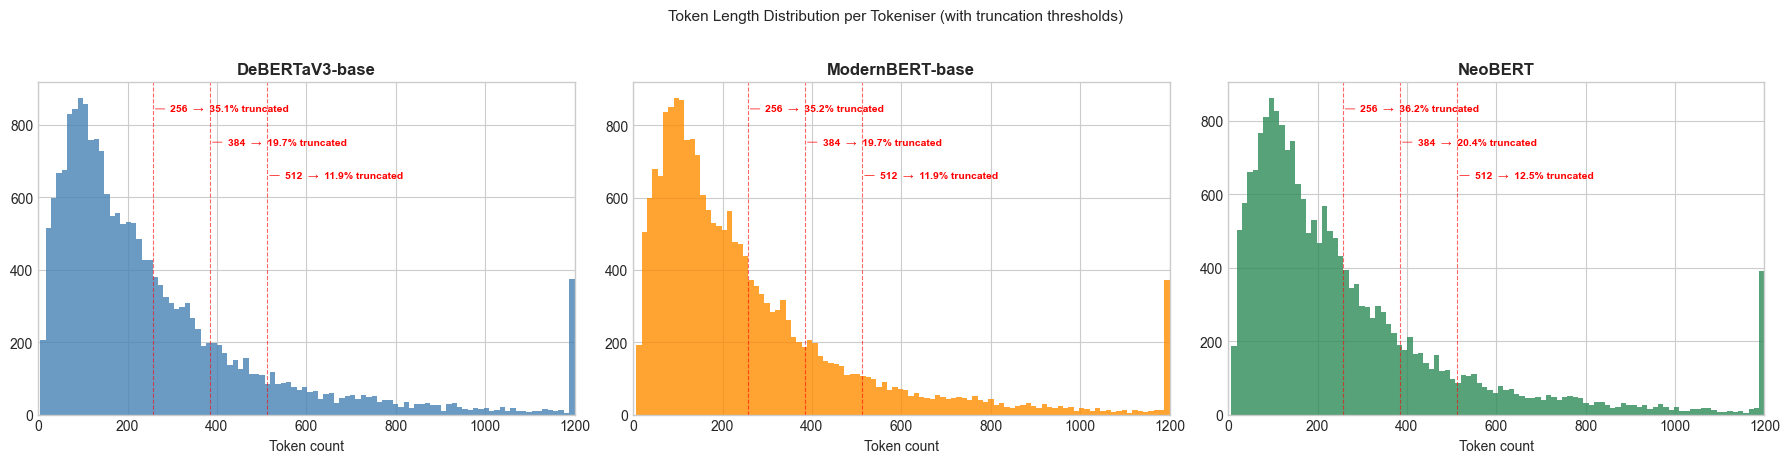

In [45]:
# Plot token length distributions per tokeniser
fig, axes = plt.subplots(1, len(token_lengths), figsize=(6 * len(token_lengths), 4.5))
if len(token_lengths) == 1:
    axes = [axes]

max_length_candidates = [256, 384, 512]
colors = ['steelblue', 'darkorange', 'seagreen']
y_offsets = [0.92, 0.82, 0.72]  # stagger labels vertically

for ax, (name, lengths), color in zip(axes, token_lengths.items(), colors):
    ax.hist(np.clip(lengths, 0, 1200), bins=100, color=color, edgecolor='none', alpha=0.8)
    ymax = ax.get_ylim()[1]
    for ml, y_off in zip(max_length_candidates, y_offsets):
        pct_truncated = (lengths > ml).mean() * 100
        ax.axvline(ml, color='red', linestyle='--', linewidth=0.8, alpha=0.6)
        ax.annotate(
            f'{ml}  →  {pct_truncated:.1f}% truncated',
            xy=(ml, ymax * y_off),
            xytext=(ml + 40, ymax * y_off),
            fontsize=7.5, color='red', fontweight='bold',
            arrowprops=dict(arrowstyle='-', color='red', lw=0.5),
            va='center',
        )
    ax.set_xlabel('Token count')
    ax.set_title(name, fontweight='bold')
    ax.set_xlim(0, 1200)

plt.suptitle('Token Length Distribution per Tokeniser (with truncation thresholds)', fontsize=11, y=1.02)
plt.tight_layout()
fig.savefig(FIG / '03_token_length_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [46]:
# Summary table for max_length decision
print(f'{"Tokeniser":20s} {"max=256":>12s} {"max=384":>12s} {"max=512":>12s}')
print('-' * 60)
for name, lengths in token_lengths.items():
    trunc_256 = (lengths > 256).mean() * 100
    trunc_384 = (lengths > 384).mean() * 100
    trunc_512 = (lengths > 512).mean() * 100
    print(f'{name:20s} {trunc_256:>10.1f}% {trunc_384:>10.1f}% {trunc_512:>10.1f}%')

print(f'\n→ max_length=512 truncates ~X% of narratives (acceptable).')
print(f'  For ModernBERT (8192 context), we could go higher, but 512 balances')
print(f'  coverage with GPU memory and training speed on 8GB VRAM.')

Tokeniser                 max=256      max=384      max=512
------------------------------------------------------------
DeBERTaV3-base             35.1%       19.7%       11.9%
ModernBERT-base            35.2%       19.7%       11.9%
NeoBERT                    36.2%       20.4%       12.5%

→ max_length=512 truncates ~X% of narratives (acceptable).
  For ModernBERT (8192 context), we could go higher, but 512 balances
  coverage with GPU memory and training speed on 8GB VRAM.


## 11 — Save Processed Datasets

Save train/val/test as parquet files. Parquet is columnar, compressed, and preserves dtypes — far more efficient than CSV for repeated loading in training notebooks.

We also save the label encoders and metadata for reproducibility.

In [47]:
# Select columns to save
save_cols = [
    # IDs and dates
    'complaint_id', 'date_received',
    # Text
    'narrative',
    # Original labels (string)
    'product', 'issue_clean', 'company_response',
    # Encoded labels (int)
    'product_id', 'issue_id', 'response_id',
    # RL reward
    'reward', 'is_timely',
    # Metadata features
    'word_count', 'char_len', 'caps_ratio', 'redacted_count',
    'amount_count', 'has_url', 'routing_days', 'channel_id',
    # Context (for RAG / analysis)
    'company', 'state', 'submitted_via', 'tags',
]

# Only keep columns that actually exist
save_cols = [c for c in save_cols if c in train_df.columns]

train_df[save_cols].to_parquet(PROCESSED / 'train.parquet', index=False)
val_df[save_cols].to_parquet(PROCESSED / 'val.parquet', index=False)
test_df[save_cols].to_parquet(PROCESSED / 'test.parquet', index=False)

print(f'Saved to {PROCESSED}:')
for name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    path = PROCESSED / f'{name}.parquet'
    size_mb = path.stat().st_size / 1e6
    print(f'  {name}.parquet: {len(split_df):>9,} rows, {size_mb:.1f} MB')

Saved to C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\data\processed:
  train.parquet: 1,813,849 rows, 1033.8 MB
  val.parquet:   331,178 rows, 189.2 MB
  test.parquet:   274,065 rows, 173.0 MB


In [48]:
train_df['product_id'].value_counts().sort_index()


product_id
0    129869
1    168930
2    956601
3    266081
4      1846
5     48354
6    124631
7     34581
8     47768
9     35188
Name: count, dtype: int64

In [54]:
# Save label encoders and config for reproducibility
import pickle

encoders = {
    'product_encoder': product_encoder,
    'issue_encoder': issue_encoder,
    'response_encoder': response_encoder,
    'channel_encoder': channel_encoder,
}

with open(PROCESSED / 'label_encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)
print('Label encoders saved to label_encoders.pkl')

# Save config as JSON for easy loading
config = {
    'n_products': n_products,
    'n_issues': n_issues,
    'n_responses': n_responses,
    'product_classes': product_encoder.classes_.tolist(),
    'issue_classes': issue_encoder.classes_.tolist(),
    'response_classes': response_encoder.classes_.tolist(),
    'response_reward_map': response_reward_map,
    'top_issues': top_issues,
    'valid_responses': valid_responses,
    'max_length': 512,
    'metadata_features': metadata_cols,
    'train_size': len(train_df),
    'val_size': len(val_df),
    'test_size': len(test_df),
    'train_cutoff': '2024-01-01',
    'val_cutoff': '2024-07-01',
}

with open(PROCESSED / 'preprocessing_config.json', 'w') as f:
    json.dump(config, f, indent=2, default=str)
print('Config saved to preprocessing_config.json')

Label encoders saved to label_encoders.pkl
Config saved to preprocessing_config.json


## 12 — PyTorch Dataset Class

Define the reusable `CFPBDataset` class that all fine-tuning notebooks (NB05–08) will import. This handles tokenisation on-the-fly so we don't store massive pre-tokenised tensors to disk.

In [55]:
%%writefile {ROOT / 'src' / 'data' / 'dataset.py'}
"""
CFPBDataset — PyTorch Dataset for CFPB complaint classification.

Handles on-the-fly tokenisation and multi-task label packaging.
Used by NB05-08 fine-tuning notebooks.
"""
import torch
from torch.utils.data import Dataset
import pandas as pd


class CFPBDataset(Dataset):
    """
    PyTorch Dataset for CFPB consumer complaints.
    
    Tokenises on-the-fly to support swapping tokenisers
    between experiments without re-processing data.
    
    Args:
        df: DataFrame with 'narrative', 'product_id', 'issue_id', 'response_id' columns
        tokeniser: HuggingFace tokeniser instance
        max_length: Maximum token sequence length (default 512)
        metadata_cols: List of metadata feature column names (optional)
    """
    def __init__(self, df, tokeniser, max_length=512, metadata_cols=None):
        self.texts = df['narrative'].tolist()
        self.product_ids = torch.tensor(df['product_id'].values, dtype=torch.long)
        self.issue_ids = torch.tensor(df['issue_id'].values, dtype=torch.long)
        self.response_ids = torch.tensor(df['response_id'].values, dtype=torch.long)
        self.rewards = torch.tensor(df['reward'].values, dtype=torch.float32)
        self.tokeniser = tokeniser
        self.max_length = max_length
        
        if metadata_cols and all(c in df.columns for c in metadata_cols):
            self.metadata = torch.tensor(
                df[metadata_cols].values, dtype=torch.float32
            )
        else:
            self.metadata = None
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        encoding = self.tokeniser(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        item = {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label_product': self.product_ids[idx],
            'label_issue': self.issue_ids[idx],
            'label_response': self.response_ids[idx],
            'reward': self.rewards[idx],
        }
        
        # Include token_type_ids if the tokeniser produces them (BERT-family)
        if 'token_type_ids' in encoding:
            item['token_type_ids'] = encoding['token_type_ids'].squeeze(0)
        
        if self.metadata is not None:
            item['metadata'] = self.metadata[idx]
        
        return item


def load_split(split_name, processed_dir='data/processed'):
    """Load a preprocessed split by name ('train', 'val', 'test')."""
    path = f'{processed_dir}/{split_name}.parquet'
    return pd.read_parquet(path)

Overwriting C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\src\data\dataset.py


In [56]:
# Quick sanity check — load back and verify
test_load = pd.read_parquet(PROCESSED / 'train.parquet')
print(f'Reload check — train.parquet: {len(test_load):,} rows, {test_load.shape[1]} columns')
print(f'Columns: {list(test_load.columns)}')
print(f'\nLabel ranges:')
print(f'  product_id:  {test_load["product_id"].min()} → {test_load["product_id"].max()} ({test_load["product_id"].nunique()} classes)')
print(f'  issue_id:    {test_load["issue_id"].min()} → {test_load["issue_id"].max()} ({test_load["issue_id"].nunique()} classes)')
print(f'  response_id: {test_load["response_id"].min()} → {test_load["response_id"].max()} ({test_load["response_id"].nunique()} classes)')
print(f'  reward:      {test_load["reward"].min():.2f} → {test_load["reward"].max():.2f}')
print(f'\nSample narrative (first 200 chars):')
print(f'  "{test_load["narrative"].iloc[0][:200]}..."')
del test_load

Reload check — train.parquet: 1,813,849 rows, 23 columns
Columns: ['complaint_id', 'date_received', 'narrative', 'product', 'issue_clean', 'company_response', 'product_id', 'issue_id', 'response_id', 'reward', 'is_timely', 'word_count', 'char_len', 'caps_ratio', 'redacted_count', 'amount_count', 'has_url', 'routing_days', 'channel_id', 'company', 'state', 'submitted_via', 'tags']

Label ranges:
  product_id:  0 → 9 (10 classes)
  issue_id:    0 → 35 (36 classes)
  response_id: 0 → 4 (5 classes)
  reward:      0.00 → 1.00

Sample narrative (first 200 chars):
  "We made several attempts to speak to someone at Portfolio Recovery Associates these past few months. In every attempt this company would hang up on us. This debt was settled by [REDACTED] back on [RED..."


## 13 — Preprocessing Summary

Complete data flow and decisions log for the record.

In [53]:
print('=' * 70)
print('PREPROCESSING PIPELINE SUMMARY')
print('=' * 70)
print()
print('Data flow:')
print(f'  Raw CSV                    → {before:>10,} total complaints')
print(f'  Filter to narratives       → narrative-only subset')
print(f'  Remove ghosts (<10 words)  → removed empty-after-redaction complaints')
print(f'  Deduplicate narratives     → removed exact duplicates')
print(f'  Language filter             → English-only (if needed)')
print(f'  Text cleaning              → XXXX→[REDACTED], amounts, dates, caps')
print(f'  Label encoding             → product({n_products}), issue({n_issues}), response({n_responses})')
print(f'  Temporal split             → train/val/test')
print()
print(f'Final splits:')
print(f'  Train: {len(train_df):>9,} (pre-2025)')
print(f'  Val:   {len(val_df):>9,} (Jan–Jun 2025)')
print(f'  Test:  {len(test_df):>9,} (Jul+ 2025)')
print()
print(f'Outputs saved to {PROCESSED}:')
print(f'  train.parquet, val.parquet, test.parquet')
print(f'  label_encoders.pkl')
print(f'  preprocessing_config.json')
print(f'  src/data/dataset.py (CFPBDataset class)')
print()
print(f'Recommended training config:')
print(f'  max_length = 512')
print(f'  Primary target: product_id ({n_products} classes)')
print(f'  Secondary target: issue_id ({n_issues} classes)')
print(f'  Tertiary target: response_id ({n_responses} classes) + reward (float)')
print(f'  Loss: Focal loss (extreme class imbalance confirmed in EDA)')
print(f'  Metric: macro-F1 (not accuracy — majority class inflates accuracy)')
print()
print('Next → NB04: DeBERTaV3-base fine-tuning')

PREPROCESSING PIPELINE SUMMARY

Data flow:
  Raw CSV                    →  2,419,220 total complaints
  Filter to narratives       → narrative-only subset
  Remove ghosts (<10 words)  → removed empty-after-redaction complaints
  Deduplicate narratives     → removed exact duplicates
  Language filter             → English-only (if needed)
  Text cleaning              → XXXX→[REDACTED], amounts, dates, caps
  Label encoding             → product(10), issue(36), response(5)
  Temporal split             → train/val/test

Final splits:
  Train: 1,813,849 (pre-2025)
  Val:     331,178 (Jan–Jun 2025)
  Test:    274,065 (Jul+ 2025)

Outputs saved to C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\data\processed:
  train.parquet, val.parquet, test.parquet
  label_encoders.pkl
  preprocessing_config.json
  src/data/dataset.py (CFPBDataset class)

Recommended training config:
  max_length = 512
  Primary target: product_id (10 classes)
  Secondary target: issue_id (36 classes)
  Te

---

**Key decisions justified:**

1. **No lowercasing** — DeBERTaV3 is cased; casing carries signal (acronyms like FCRA, FDCPA, APR)
2. **No stopword removal** — transformers learn context from full sentences; removing stopwords breaks attention patterns
3. **No stemming/lemmatisation** — pre-neural technique; subword tokenisers learn morphology naturally
4. **XXXX → [REDACTED]** — standardises variable-length redaction into one learnable token
5. **Collapsed [REDACTED] sequences** — "XXXX XXXX XXXX" → one token, not three (reduces noise)
6. **Dollar amounts → [AMOUNT]** — preserves "money involved" semantics without memorising values
7. **Temporal split** — mirrors deployment reality; tests generalisation under distribution shift
8. **Issue collapse to top-N + Other** — prevents 100+ class head with many zero-shot classes
9. **consumer_disputed excluded** — discontinued April 2017, unusable for modern data
10. **On-the-fly tokenisation in Dataset** — allows swapping tokenisers per experiment without re-processing

**Next:** Notebook 04 — DeBERTaV3-base Fine-Tuning 